# 🧠 Fake News Detection using Neural Network
### SMIT — Batch 10 | AI & Data Science
---

## 📦 Step 1: Install pip

In [7]:
# Installation of !pip
!pip install tensorflow nltk pandas numpy scikit-learn matplotlib seaborn

## 📦 Step 2: Install Libraries

In [9]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

nltk.download('stopwords')
nltk.download('wordnet')
print("All libraries loaded!")

All libraries loaded!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 🗂️ Step 3: Load & Explore Dataset

In [12]:
# Cleaning Data
df = pd.read_csv('fake_real_news.csv')

## label column ='target'
df = df[['text', 'target']]
df = df.rename(columns={'target': 'label'})
df = df.dropna()
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())
df.head()

(44898, 2)
label
1    23481
0    21417
Name: count, dtype: int64


,text,label
0,BERLIN (Reuters) - Environmental policy domina...,0
1,BAGHDAD (Reuters) - The U.S. embassy in Iraq c...,0
2,Kim Kardashian West just went through a hellis...,1
3,Trump bashes China so much and blames them for...,1
4,WASHINGTON (Reuters) - U.S. President Donald T...,0


In [13]:
# 1. "Total null values"
print("=== Null Values ===")
print(df.isnull().sum())

# 2. "Duplicate Values"
print("\n=== Duplicate Rows ===")
print("Duplicates:", df.duplicated().sum())

# 3. "Overall info"
print("\n=== Dataset Info ===")
print(df.info())

=== Null Values ===
text     0
label    0
dtype: int64

=== Duplicate Rows ===
Duplicates: 6251

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB
None


## 🧹 Step 4: Text Preprocessing

In [15]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^\w\s]', '', text)         # remove punctuation
    text = re.sub(r'\d+', '', text)              # remove numbers
    words = text.split()
    words = [w for w in words if w not in stop_words]  # stopwords
    words = [lemmatizer.lemmatize(w) for w in words]      # lemmatize
    return ' '.join(words)

df['clean_text'] = df['text'].apply(clean_text)
print("Before:", df['text'][0][:100])
print("After :", df['clean_text'][0][:100])

Before: BERLIN (Reuters) - Environmental policy dominated negotiations on forming a new German coalition on 
After : berlin reuters environmental policy dominated negotiation forming new german coalition monday green 


## 🔢 Step 5: Tokenization & Padding

In [16]:
MAX_WORDS = 10000   # vocabulary size
MAX_LEN   = 200     # sequence length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded    = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Vocab size:", len(tokenizer.word_index))
print("Padded shape:", padded.shape)

Vocab size: 203247
Padded shape: (44898, 200)


## ✂️ Step 6: Train / Test Split

In [17]:
X = padded
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (35918, 200) | Test: (8980, 200)


## 🤖 Step 7: LSTM Model

In [18]:
lstm_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),              # Bonus: Dropout layer
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 🔶 Step 8: LSTM Model Training
> LSTM ko train kar rahe hain — 9 epochs, batch size 64
---

In [19]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=9,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 85s 162ms/step - accuracy: 0.7477 - loss: 0.4875 - val_accuracy: 0.8363 - val_loss: 0.3679
Epoch 2/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 79s 156ms/step - accuracy: 0.8719 - loss: 0.3291 - val_accuracy: 0.9530 - val_loss: 0.1833
Epoch 3/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.9449 - loss: 0.2000 - val_accuracy: 0.9630 - val_loss: 0.1450
Epoch 4/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 82s 156ms/step - accuracy: 0.9361 - loss: 0.2213 - val_accuracy: 0.9343 - val_loss: 0.2015
Epoch 5/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 81s 154ms/step - accuracy: 0.9440 - loss: 0.1726 - val_accuracy: 0.9630 - val_loss: 0.1310
Epoch 6/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 82s 154ms/step - accuracy: 0.9492 - loss: 0.1727 - val_accuracy: 0.8680 - val_loss: 0.3128
Epoch 7/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - accuracy: 0.9264 - loss: 0.2083 - val_accuracy: 0.8906 - val_loss: 0.2910
Epoch 8/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 82s 162ms/step - accuracy: 0.9228 - loss: 0.2207 - 

## 🔷 Step 9: Dense Model (Bonus — Comparison with LSTM)
> Simple Dense Network — LSTM se compare karne ke liye
---

In [21]:
dense_model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

dense_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

dense_history = dense_model.fit(
    X_train, y_train,
    epochs=9,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.9292 - loss: 0.1651 - val_accuracy: 0.9872 - val_loss: 0.0433
Epoch 2/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9889 - loss: 0.0339 - val_accuracy: 0.9916 - val_loss: 0.0317
Epoch 3/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9928 - val_loss: 0.0320
Epoch 4/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9975 - loss: 0.0090 - val_accuracy: 0.9950 - val_loss: 0.0322
Epoch 5/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9938 - loss: 0.0193 - val_accuracy: 0.9928 - val_loss: 0.0378
Epoch 6/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9977 - loss: 0.0075 - val_accuracy: 0.9925 - val_loss: 0.0401
Epoch 7/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9990 - loss: 0.0041 - val_accuracy: 0.9930 - val_loss: 0.0394
Epoch 8/9
506/506 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9975 - loss: 0.0078 - val_accuracy: 

## 📊 Step 10: Evaluation & Results

In [22]:
# LSTM evaluation
lstm_preds = (lstm_model.predict(X_test) > 0.5).astype('int32')
print("=== LSTM Model ===")
print("Accuracy:", accuracy_score(y_test, lstm_preds))
print(classification_report(y_test, lstm_preds, target_names=['Fake', 'Real']))

# Dense evaluation
dense_preds = (dense_model.predict(X_test) > 0.5).astype('int32')
print("=== Dense Model ===")
print("Accuracy:", accuracy_score(y_test, dense_preds))
print(classification_report(y_test, dense_preds, target_names=['Fake', 'Real']))

281/281 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step
=== LSTM Model ===
Accuracy: 0.9668151447661469
              precision    recall  f1-score   support

        Fake       0.99      0.94      0.96      4291
        Real       0.95      0.99      0.97      4689

    accuracy                           0.97      8980
   macro avg       0.97      0.97      0.97      8980
weighted avg       0.97      0.97      0.97      8980

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
=== Dense Model ===
Accuracy: 0.9937639198218263
              precision    recall  f1-score   support

        Fake       0.99      0.99      0.99      4291
        Real       0.99      0.99      0.99      4689

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## 📈 Step 11: Accuracy & Loss Graphs

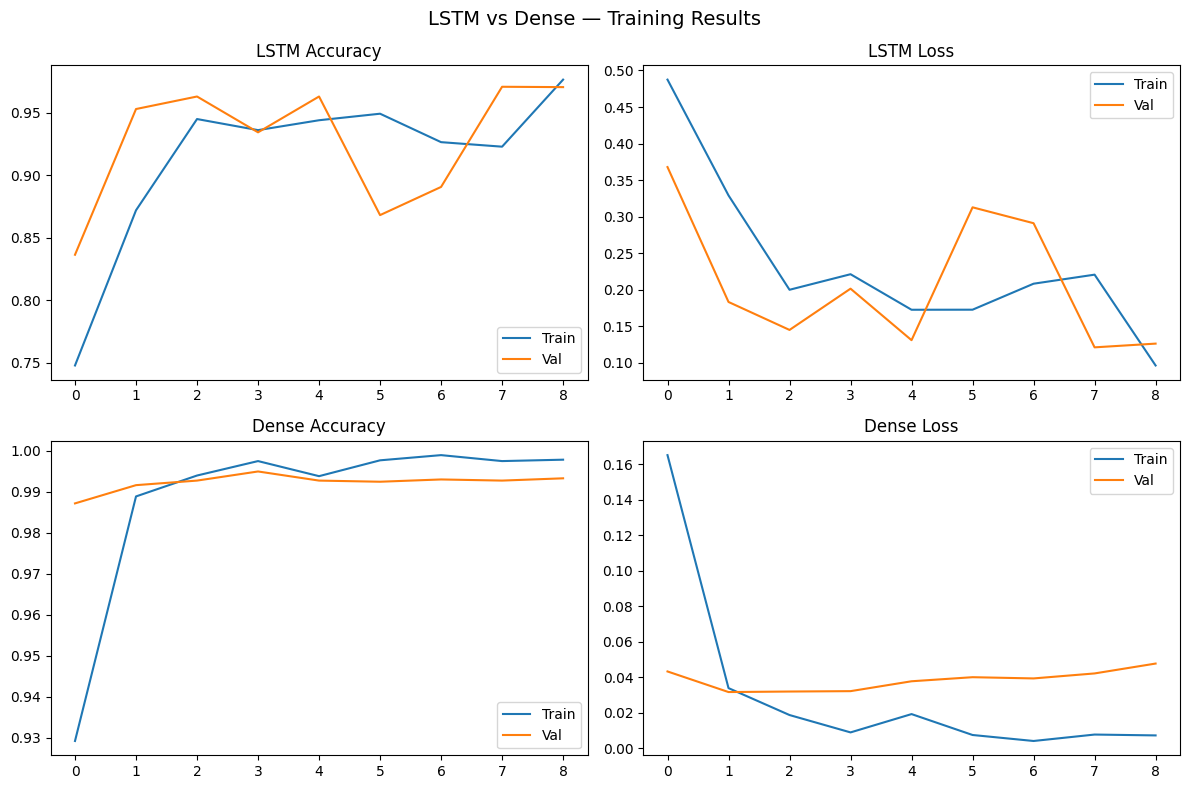

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('LSTM vs Dense — Training Results', fontsize=14)

# LSTM Accuracy
axes[0,0].plot(lstm_history.history['accuracy'], label='Train')
axes[0,0].plot(lstm_history.history['val_accuracy'], label='Val')
axes[0,0].set_title('LSTM Accuracy'); axes[0,0].legend()

# LSTM Loss
axes[0,1].plot(lstm_history.history['loss'], label='Train')
axes[0,1].plot(lstm_history.history['val_loss'], label='Val')
axes[0,1].set_title('LSTM Loss'); axes[0,1].legend()

# Dense Accuracy
axes[1,0].plot(dense_history.history['accuracy'], label='Train')
axes[1,0].plot(dense_history.history['val_accuracy'], label='Val')
axes[1,0].set_title('Dense Accuracy'); axes[1,0].legend()

# Dense Loss
axes[1,1].plot(dense_history.history['loss'], label='Train')
axes[1,1].plot(dense_history.history['val_loss'], label='Val')
axes[1,1].set_title('Dense Loss'); axes[1,1].legend()

plt.tight_layout()
plt.show()

## 🔮 Step 12: Prediction Function

In [24]:
def predict_news(text, model=lstm_model):
    cleaned  = clean_text(text)
    seq      = tokenizer.texts_to_sequences([cleaned])
    padded_s = pad_sequences(seq, maxlen=MAX_LEN, padding='post')
    pred     = model.predict(padded_s)[0][0]
    label    = "Real" if pred > 0.5 else "Fake"
    print(f"Prediction: {label} (confidence: {pred:.2f})")
    return label

# Test it!
predict_news("The president signed a new bill today in Congress")
predict_news("Aliens have taken over the White House secretly")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction: Real (confidence: 0.98)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: Real (confidence: 0.98)


'Real'

## 🧪 Let's Put LSTM to the Test!
> Can our model spot the fake ones? Let's find out...
---

In [25]:
test_headlines = [
    "NASA confirms discovery of water on Mars surface",
    "Barack Obama secretly a member of Illuminati",
    "Federal Reserve raises interest rates by 0.25 percent",
    "Scientists discover drinking bleach cures cancer instantly",
    "United Nations holds emergency meeting on climate change"
]

print("=" * 50)
print("       LSTM Model Predictions")
print("=" * 50)

for news in test_headlines:
    pred = lstm_model.predict(
        pad_sequences(tokenizer.texts_to_sequences([clean_text(news)]),
        maxlen=MAX_LEN, padding='post'), verbose=0)[0][0]

    label = "✅ Real" if pred > 0.5 else "❌ Fake"
    print(f"{label} | {news[:45]}")

print("=" * 50)

       LSTM Model Predictions
❌ Fake | NASA confirms discovery of water on Mars surf
✅ Real | Barack Obama secretly a member of Illuminati
❌ Fake | Federal Reserve raises interest rates by 0.25
✅ Real | Scientists discover drinking bleach cures can
✅ Real | United Nations holds emergency meeting on cli


## 📊 How Well Did LSTM Learn? — Accuracy Check
---

In [26]:
lstm_preds = (lstm_model.predict(X_test) > 0.5).astype('int32')
print("LSTM Accuracy:", accuracy_score(y_test, lstm_preds))

281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step
LSTM Accuracy: 0.9668151447661469


## 🎯 Real vs Fake — LSTM Final Test
> Political headlines
---

In [27]:
test_headlines = [
    "Trump signs executive order on immigration policy",
    "Hillary Clinton arrested for email scandal confirmed",
    "Senate passes new healthcare bill with bipartisan support",
    "Pope Francis secretly controls world government sources say",
    "FBI investigates Russian interference in US election"
]

print("=" * 55)
print("        LSTM Model Predictions")
print("=" * 55)

for news in test_headlines:
    pred = lstm_model.predict(
        pad_sequences(tokenizer.texts_to_sequences([clean_text(news)]),
        maxlen=MAX_LEN, padding='post'), verbose=0)[0][0]

    label = "✅ Real" if pred > 0.5 else "❌ Fake"
    confidence = f"{pred:.2f}"
    print(f"{label} ({confidence}) | {news[:45]}")

print("=" * 55)

        LSTM Model Predictions
❌ Fake (0.14) | Trump signs executive order on immigration po
✅ Real (0.98) | Hillary Clinton arrested for email scandal co
✅ Real (0.98) | Senate passes new healthcare bill with bipart
✅ Real (0.98) | Pope Francis secretly controls world governme
✅ Real (0.98) | FBI investigates Russian interference in US e


## 🕵️ Mission Accomplished — Fake News Detector is Live!😎🔥
---